In [1]:
!pip install tensorflow tensorflow_hub

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [3]:
from google.colab import files

uploaded = files.upload()

Saving content.jpg to content.jpg
Saving style.jpg to style.jpg


In [4]:
def load_image(path):
    img = Image.open(path)
    img = img.resize((256,256))
    img = np.array(img)/255.0
    img = img[np.newaxis, :]
    return tf.constant(img, dtype=tf.float32)

content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

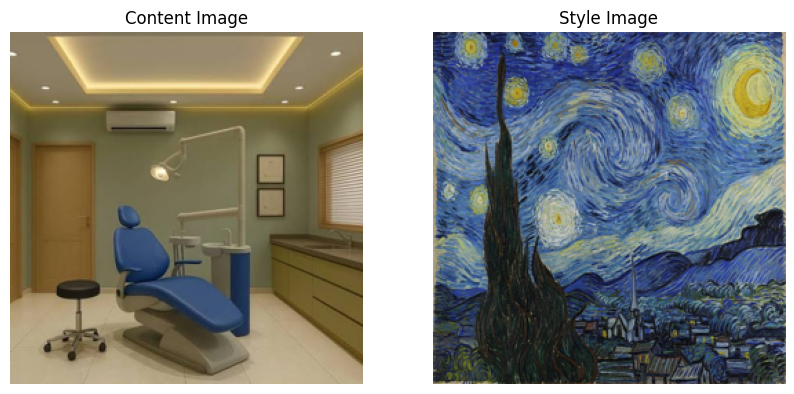

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(content_image[0])
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(style_image[0])
plt.title("Style Image")
plt.axis("off")

plt.show()

In [5]:
hub_model = hub.load(
    'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
)

In [6]:
stylized_image = hub_model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

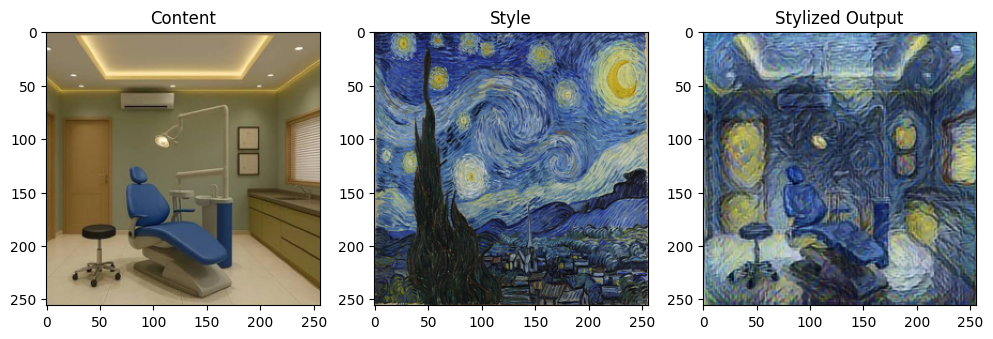

In [7]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(content_image[0])
plt.title("Content")

plt.subplot(1,3,2)
plt.imshow(style_image[0])
plt.title("Style")

plt.subplot(1,3,3)
plt.imshow(stylized_image[0])
plt.title("Stylized Output")

plt.show()